# Multiplicative Wealth-in-Utility with Portfolio Choice

The `WealthUtilityConsumerType` models consumers who get [utility directly from holding wealth](../ConsWealthUtilityModel/WealthUtilityConsumerType.ipynb), in a multiplicative interaction with consumption. The `RiskyAssetConsumerType` concerns consumers who [allocate their wealth between a risky and risk-free asset](../ConsPortfolioModel/RiskyAssetConsumerType.ipynb). The `WealthPortfolioConsumerType` asks the critical question: *¿Porque no los dos?*

In [1]:
from HARK.ConsumptionSaving.ConsWealthPortfolioModel import (
    WealthPortfolioConsumerType,
    init_wealth_portfolio,
)
from HARK.models import (
    RiskyAssetConsumerType,
    WealthUtilityConsumerType,
    IndShockConsumerType,
)
import matplotlib.pyplot as plt
from HARK.utilities import plot_funcs
from time import time


def mystr(x):
    return "{:.4f}".format(x)

$\newcommand{\CRRA}{\rho}$
$\newcommand{\LivPrb}{\mathsf{S}}$
$\newcommand{\DiscFac}{\beta}$
$\newcommand{\WealthShare}{\alpha}$
$\newcommand{\WealthShift}{\xi}$
$\newcommand{\PermGroFac}{\Gamma}$
$\newcommand{\Rfree}{\mathsf{R}}$
$\newcommand{\Risky}{\mathfrak{R}}$


## Wealth-in-Utility with Portfolio Choice Model Statement

The model for a `WealthPortfolioConsumerType` combines the key elements from `RiskyAssetConsumerType` and `WealthUtilityConsumerType`. It can be written in Bellman form as:

\begin{align*}
\text{v}_t(m_t) &= \max_{c_t, s_t} \frac{x_t^{1-\CRRA}}{1-\CRRA} + \LivPrb_t \DiscFac \mathbb{E} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{1-\CRRA}\text{v}_{t+1}(m_{t+1}) \right] \\
&\text{s.t.} \\
x_t &= (a_t + \WealthShift)^\WealthShare c_t^{1-\WealthShare}, \\
a_t &= m_t - c_t, \\
a_t &\geq 0, \\
s_t &\in [0,1], \\
m_{t+1} &= a_t R_{t+1}/(\PermGroFac_{t+1} \psi_{t+1}) + \theta_{t+1}, \\
R_{t+1} &= s_t \Risky_{t+1} + (1-s_t) \Rfree, \\
(\psi_{t+1},\theta_{t+1}) &\sim F_{t+1}, \\
\Risky_{t+1} &\sim G, \\
\mathbb{E}[\psi] &= 1. \\
\end{align*}

As in the base wealth-in-utility model, the agent has CRRA preferences over a composite of (adjusted) wealth $a_t + \WealthShift$ with share $\WealthShare$ and consumption $c_t$ with complementary share $1-\WealthShare$. In addition to choosing how much to consume and how much to retain in assets $a_t$, the agent also chooses the proportion of their wealth $s_t$ to allocate to the risky asset; the remainder is put into the risk-free asset.

As in the base risky asset model, the risk-free asset has a return of $\Rfree$, and the risky asset has return $\Risky_t$ distributed on $G$. The portfolio return $R_t$ is the average of the risk-free and risky return, weighted by the agent's chosen risky asset share $s_t$. As usual, we do not allow the agent to short either asset, so $s_t$ is strictly on the unit interval. Moreover, borrowing is not allowed and the artificial borrow constraint $a_t \geq 0$ is "hardwired" into the model.

## Example parameters to construct a `WealthPortfolioConsumerType`

The default parameters for a `WealthPortfolioConsumerType` are mostly a combination of those for `PortfolioConsumerType` and `WealthUtilityConsumerType`, as you might expect.

| Parameter | Description | Code | Example value | Time-varying? |
| :---: | --- | --- | --- | --- |
| $\DiscFac$ |Intertemporal discount factor  | `DiscFac` | $0.90$ |  |
| $\CRRA$ |Coefficient of relative risk aversion | `CRRA` | $5.0$ | |
| $\WealthShare$ | Share of wealth in Cobb-Douglas combination | `WealthShare` | $0.5$ | |
| $\WealthShift$ | Additive shifter for wealth in Cobb-Douglas combination | `WealthShift` | $0.1$ | |
| $\Rfree_t$ | Risk free interest factor | `Rfree` | $[1.03]$ | $\surd$ |
| $\mu_\Risky$ | Mean risky asset return | `RiskyAvg` | $1.08$ | |
| $\sigma_\Risky$ | Standard deviation of log risky asset return | `RiskyStd` | $0.1836$ | |
| $N_\Risky$ | Number of equiprobable nodes in risky asset return distribution | `RiskyCount` | $5$ | |
| $\LivPrb_t$ |Survival probability | `LivPrb` | $[0.98]$ | $\surd$ |
| $\PermGroFac_{t}$ |Permanent income growth factor| `PermGroFac` | $[1.01]$ | $\surd$ |
| $\sigma_\psi$| Standard deviation of log permanent income shocks | `PermShkStd` | $[0.1]$ |$\surd$ |
| $N_\psi$| Number of discrete permanent income shocks | `PermShkCount` | $7$ | |
| $\sigma_\theta$| Standard deviation of log transitory income shocks | `TranShkStd` | $[0.1]$ | $\surd$ |
| $N_\theta$| Number of discrete transitory income shocks | `TranShkCount` | $7$ |  |
| $\mho$ | Probability of being unemployed and getting $\theta=\underline{\theta}$ | `UnempPrb` | $0.05$ |  |
| $\underline{\theta}$| Transitory shock when unemployed | `IncUnemp` | $0.3$ |  |
| $\mho^{Ret}$ | Probability of being "unemployed" when retired | `UnempPrbRet` | $0.0005$ |  |
| $\underline{\theta}^{Ret}$| Transitory shock when "unemployed" and retired | `IncUnempRet` | $0.0$ |  |
| $(none)$ | Period of the lifecycle model when retirement begins | `T_retire` | $0$ | |
| $(none)$ | Minimum value in assets-above-minimum grid | `aXtraMin` | $0.001$ | |
| $(none)$ | Maximum value in assets-above-minimum grid | `aXtraMax` | $100.0$ | |
| $(none)$ | Number of points in base assets-above-minimum grid | `aXtraCount` | $200$ | |
| $(none)$ | Exponential nesting factor for base assets-above-minimum grid | `aXtraNestFac` | $1$ | |
| $(none)$ | Additional values to add to assets-above-minimum grid | `aXtraExtra` | $None$ | |
| $(none)$ | Number of discrete points in risky share grid | `ShareCount` | $25$ | |
| $(none)$ | Number of gridpoints in chi-from-omega function $f$ | `ChiFromOmega_N` | $501$ | |
| $(none)$ | Absolute magnitude of the bounds of $z$ in $f$ | `ChiFromOmega_bound` | $15.0$ | |

The method for finding optimal consumption for a `WealthPortfolioConsumerType` follows the same procedure as a `WealthUtilityConsumerType`, so the parameters include the primitive values to construct the interpolant `ChiFromOmegaFunction`.

**NB:** For compatibility reasons (related to class inheritance), the `WealthPortfolioConsumerType` also has default parameter values for `DiscreteShareBool`, `PortfolioBool`, `PortfolioBisect`, `IndepDstnBool`, `vFuncBool`, `CubicBool`, `AdjustPrb`, and `RiskyShareFixed`. These parameters are never referenced and have no effect on the model, but must exist. This issue will be rectified soon.

## Example implementation of `WealthPortfolioConsumerType`

Because the model is based on both `RiskyAssetConsumerType` and on `WealthUtilityConsumerType`, it is useful to compare the solution to this model against those of the two parent models. Morever, both of those models are themselves extensions of the workhorse `IndShockConsumerType`, which we also include as a comparitor. Below, we use the default parameter dictionary `init_wealth_portfolio` because it contains a superset of the parameters required for each of `RiskyAssetConsumerType`, `WealthUtilityConsumerType`, and `IndShockConsumerType`.

In [2]:
# Make and solve an infinite horizon WealthPortfolioConsumerType with default parameters
WealthPortfolioExample = WealthPortfolioConsumerType(cycles=0)
t0 = time()
WealthPortfolioExample.solve()
WealthPortfolioExample.unpack("cFuncAdj")
WealthPortfolioExample.unpack("ShareFuncAdj")
t1 = time()
print(
    "Solving an infinite horizon wealth-portfolio consumer took "
    + mystr(t1 - t0)
    + " seconds."
)

Solving an infinite horizon wealth-portfolio consumer took 0.5183 seconds.


In [3]:
# Adjust the parameter dictionary to make it infinite horizon and not change constructors
my_params = init_wealth_portfolio.copy()
del my_params["constructors"]
my_params["cycles"] = 0

In [4]:
# Make and solve an infinite horizon WealthUtilityConsumerType with parameters for the WealthPortfolioConsumerType
WealthUtilityExample = WealthUtilityConsumerType(**my_params)
t0 = time()
WealthUtilityExample.solve()
WealthUtilityExample.unpack("cFunc")
t1 = time()
print(
    "Solving an infinite horizon wealth-in-utility consumer took "
    + mystr(t1 - t0)
    + " seconds."
)

Solving an infinite horizon wealth-in-utility consumer took 0.2061 seconds.


In [5]:
# Make and solve an infinite horizon RiskyAssetConsumerType with parameters for the WealthPortfolioConsumerType
RiskyAssetExample = RiskyAssetConsumerType(**my_params)
t0 = time()
RiskyAssetExample.solve()
RiskyAssetExample.unpack("cFunc")
RiskyAssetExample.unpack("ShareFunc")
t1 = time()
print(
    "Solving an infinite horizon portfolio choice consumer took "
    + mystr(t1 - t0)
    + " seconds."
)

Solving an infinite horizon portfolio choice consumer took 3.5051 seconds.


In [6]:
# Make and solve an ordinary idiosyncratic shocks consumer type with the parameters for WealthPortfolioConsumerType
IndShockExample = IndShockConsumerType(**my_params)
t0 = time()
IndShockExample.solve()
IndShockExample.unpack("cFunc")
t1 = time()
print("Solving an infinite horizon basic consumer took " + mystr(t1 - t0) + " seconds.")

Solving an infinite horizon basic consumer took 0.4226 seconds.


The consumption functions for the two wealth-in-utility models (blue and green) is no greater than the consumption function for two models without wealth-in-utility (orange and red) other than at extremely low $m_t$. In fact, latter functions are usually significantly higher. When the agent values wealth in itself (rather than only as a means to finance future consumption), they will want to save more and consume less.

Comparing the consumption functions for models with and without portfolio choice, note that agents with portfolio choice expect to have higher market resources in the future because they are able to save in the higher return risky asset. Thus for almost the entire state space, the orange consumption function exceeds the red one, and the blue consumption function exceeds the green one. At fairly low values of $m_t$ (say, $m_t < 1$), the additional risk from risky asset returns actually pushes consumption with portfolio choice slight *below* the consumption function with only a risk-free asset.

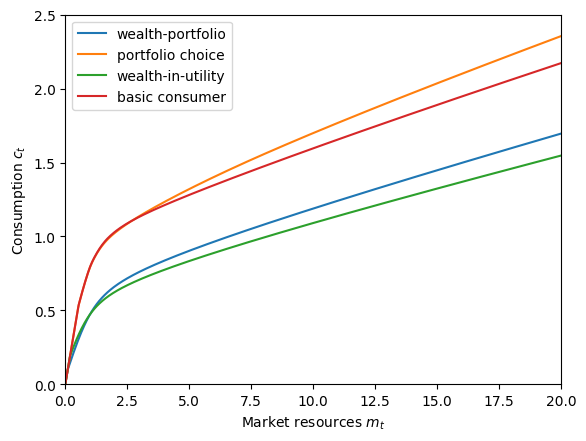

In [7]:
# Plot the consumption functions against each other
plt.ylim(0.0, 2.5)
plot_funcs(
    [
        WealthPortfolioExample.cFuncAdj[0],
        RiskyAssetExample.cFunc[0],
        WealthUtilityExample.cFunc[0],
        IndShockExample.cFunc[0],
    ],
    0.0,
    20.0,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Consumption $c_t$",
    legend_kwds={
        "labels": [
            "wealth-portfolio",
            "portfolio choice",
            "wealth-in-utility",
            "basic consumer",
        ],
        "loc": 2,
    },
)

When comparing the optimal risky share functions for the two models with portfolio choice, it should not be surprising that consumers in the wealth-portfolio model choose to allocate a lower fraction of their wealth to risky assets than the baseline portfolio choice consumers. When wealth enters the utility function directly, fluctuations in future wealth through risky assets don't just have indirect utility effects through consumption fluctuation, but a *direct* utility effect through variance in wealth. Risk averse consumers do not want to be exposed to so much risk, so they put *less* into the risky asset when wealth is an argument to the utility function.

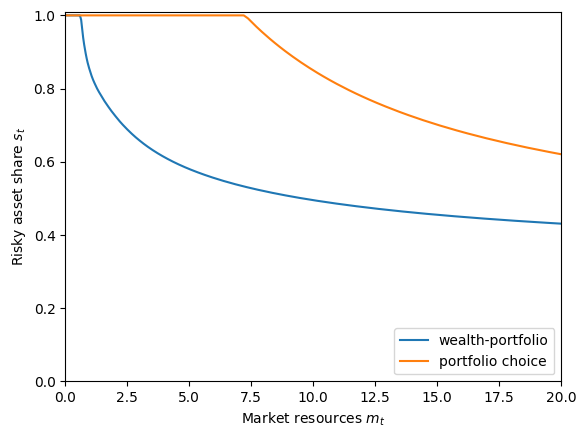

In [8]:
# Plot the optimal risky share functions against each other
plt.ylim(0.0, 1.01)
plot_funcs(
    [WealthPortfolioExample.ShareFuncAdj[0], RiskyAssetExample.ShareFunc[0]],
    0.0,
    20.0,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Risky asset share $s_t$",
    legend_kwds={"labels": ["wealth-portfolio", "portfolio choice"], "loc": 4},
)